# 🤖 Model Training Pipeline — Flood Prediction

**Covers:** Baseline Model, Model Selection, Cross Validation, Training, Evaluation, Error Analysis, Optimization, Explainability, Save Model

**All files are manually uploaded and downloaded.**

---
## 📤 Upload Processed Data

In [ ]:
# ============================================================
# UPLOAD: train.csv, val.csv, pipeline_metadata.json
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import time
import io
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- Upload files ---
try:
    from google.colab import files
    print('📤 Upload train.csv:')
    up1 = files.upload()
    train_df = pd.read_csv(io.BytesIO(list(up1.values())[0]))
    print('\n📤 Upload val.csv:')
    up2 = files.upload()
    val_df = pd.read_csv(io.BytesIO(list(up2.values())[0]))
    print('\n📤 Upload pipeline_metadata.json:')
    up3 = files.upload()
    metadata = json.loads(list(up3.values())[0].decode('utf-8'))
except ImportError:
    try:
        import tkinter as tk
        from tkinter import filedialog
        root = tk.Tk(); root.withdraw()
        print('📤 Select train.csv:')
        p1 = filedialog.askopenfilename(title='Select train.csv', filetypes=[('CSV','*.csv')])
        train_df = pd.read_csv(p1)
        print('📤 Select val.csv:')
        p2 = filedialog.askopenfilename(title='Select val.csv', filetypes=[('CSV','*.csv')])
        val_df = pd.read_csv(p2)
        print('📤 Select pipeline_metadata.json:')
        p3 = filedialog.askopenfilename(title='Select pipeline_metadata.json', filetypes=[('JSON','*.json')])
        with open(p3, 'r') as f:
            metadata = json.load(f)
        root.destroy()
    except Exception:
        p1 = input('Enter path to train.csv: ').strip().strip('"')
        train_df = pd.read_csv(p1)
        p2 = input('Enter path to val.csv: ').strip().strip('"')
        val_df = pd.read_csv(p2)
        p3 = input('Enter path to pipeline_metadata.json: ').strip().strip('"')
        with open(p3, 'r') as f:
            metadata = json.load(f)

TARGET_COL = metadata['target_column']
PROBLEM_TYPE = metadata['problem_type']
IMBALANCED = metadata.get('imbalanced', False)

X_train = train_df.drop(columns=[TARGET_COL])
y_train = train_df[TARGET_COL]
X_val = val_df.drop(columns=[TARGET_COL])
y_val = val_df[TARGET_COL]

print(f'\n{"="*60}')
print('📥 DATA LOADED')
print(f'{"="*60}')
print(f'  Problem: {PROBLEM_TYPE.upper()} | Imbalanced: {IMBALANCED}')
print(f'  Train: {X_train.shape} | Val: {X_val.shape}')
print(f'  Target (Train): {dict(y_train.value_counts())}')

📤 Upload train.csv:


Saving train.csv to train.csv

📤 Upload val.csv:


Saving val.csv to val.csv

📤 Upload pipeline_metadata.json:


Saving pipeline_metadata.json to pipeline_metadata.json

📥 DATA LOADED
  Problem: CLASSIFICATION | Imbalanced: True
  Train: (17500, 43) | Val: (3750, 43)
  Target (Train): {0: np.int64(15770), 1: np.int64(1730)}


---
## 🔟 Baseline Model

In [ ]:
# ============================================================
# 10. BASELINE MODEL
# ============================================================
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score,
    mean_squared_error, mean_absolute_error, r2_score
)

print(f'{"="*60}')
print('📏 BASELINE MODEL')
print(f'{"="*60}')

baselines = {}
if PROBLEM_TYPE == 'classification':
    avg = 'weighted' if metadata['n_classes'] > 2 else 'binary'
    for strategy in ['most_frequent', 'stratified', 'uniform']:
        dummy = DummyClassifier(strategy=strategy, random_state=RANDOM_STATE)
        dummy.fit(X_train, y_train)
        y_pred_d = dummy.predict(X_val)
        baselines[f'Dummy ({strategy})'] = {
            'Accuracy': accuracy_score(y_val, y_pred_d),
            'F1': f1_score(y_val, y_pred_d, average=avg, zero_division=0),
            'Precision': precision_score(y_val, y_pred_d, average=avg, zero_division=0),
            'Recall': recall_score(y_val, y_pred_d, average=avg, zero_division=0)
        }
    baseline_df = pd.DataFrame(baselines).T
    BASELINE_F1 = float(baseline_df['F1'].max())
    print(f'  ⚠️ Any model must beat F1 = {BASELINE_F1:.4f}')
else:
    for strategy in ['mean', 'median']:
        dummy = DummyRegressor(strategy=strategy)
        dummy.fit(X_train, y_train)
        y_pred_d = dummy.predict(X_val)
        baselines[f'Dummy ({strategy})'] = {
            'RMSE': np.sqrt(mean_squared_error(y_val, y_pred_d)),
            'MAE': mean_absolute_error(y_val, y_pred_d),
            'R²': r2_score(y_val, y_pred_d)
        }
    baseline_df = pd.DataFrame(baselines).T
    BASELINE_RMSE = float(baseline_df['RMSE'].min())

display(baseline_df)

📏 BASELINE MODEL
  ⚠️ Any model must beat F1 = 0.1674


,Accuracy,F1,Precision,Recall
Dummy (most_frequent),0.901067,0.000000,0.000000,0.000000
Dummy (stratified),0.818667,0.063361,0.064789,0.061995
Dummy (uniform),0.501333,0.167409,0.100267,0.506739


---
## 1️⃣1️⃣ Model Selection + 1️⃣3️⃣ Training

In [ ]:
# ============================================================
# 11 + 13. MODEL SELECTION + TRAINING
# ============================================================
from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    GradientBoostingClassifier, GradientBoostingRegressor,
    AdaBoostClassifier, AdaBoostRegressor,
    ExtraTreesClassifier, ExtraTreesRegressor
)
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.naive_bayes import GaussianNB

HAS_XGB = False
try:
    from xgboost import XGBClassifier, XGBRegressor
    HAS_XGB = True
except ImportError:
    print('⚠️ XGBoost not installed.')

HAS_LGBM = False
try:
    from lightgbm import LGBMClassifier, LGBMRegressor
    HAS_LGBM = True
except ImportError:
    print('⚠️ LightGBM not installed.')

cw = 'balanced' if IMBALANCED else None

if PROBLEM_TYPE == 'classification':
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight=cw),
        'Random Forest': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1, class_weight=cw),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE),
        'Extra Trees': ExtraTreesClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1, class_weight=cw),
        'KNN': KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
        'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight=cw),
        'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=RANDOM_STATE, algorithm='SAMME'),
        'Naive Bayes': GaussianNB(),
    }
    if HAS_XGB:
        spw = float((y_train == 0).sum()) / max(float((y_train == 1).sum()), 1) if IMBALANCED else 1
        models['XGBoost'] = XGBClassifier(n_estimators=200, random_state=RANDOM_STATE, use_label_encoder=False, eval_metric='logloss', verbosity=0, n_jobs=-1, scale_pos_weight=spw)
    if HAS_LGBM:
        models['LightGBM'] = LGBMClassifier(n_estimators=200, random_state=RANDOM_STATE, verbosity=-1, n_jobs=-1, is_unbalance=IMBALANCED)
else:
    models = {
        'Ridge': Ridge(),
        'Lasso': Lasso(),
        'Random Forest': RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, random_state=RANDOM_STATE),
        'Extra Trees': ExtraTreesRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
        'KNN': KNeighborsRegressor(n_neighbors=7, n_jobs=-1),
        'Decision Tree': DecisionTreeRegressor(random_state=RANDOM_STATE),
        'AdaBoost': AdaBoostRegressor(n_estimators=100, random_state=RANDOM_STATE),
    }
    if HAS_XGB:
        models['XGBoost'] = XGBRegressor(n_estimators=200, random_state=RANDOM_STATE, verbosity=0, n_jobs=-1)
    if HAS_LGBM:
        models['LightGBM'] = LGBMRegressor(n_estimators=200, random_state=RANDOM_STATE, verbosity=-1, n_jobs=-1)

print(f'{"="*60}')
print(f'🤖 TRAINING {len(models)} MODELS')
print(f'{"="*60}')

results = {}
trained_models = {}

for name, model in models.items():
    print(f'  🔄 {name}...', end=' ')
    start = time.time()
    try:
        model.fit(X_train, y_train)
        elapsed = time.time() - start
        y_pred_t = model.predict(X_train)
        y_pred_v = model.predict(X_val)
        if PROBLEM_TYPE == 'classification':
            res = {
                'Train Acc': accuracy_score(y_train, y_pred_t),
                'Val Acc': accuracy_score(y_val, y_pred_v),
                'Val Precision': precision_score(y_val, y_pred_v, average=avg, zero_division=0),
                'Val Recall': recall_score(y_val, y_pred_v, average=avg, zero_division=0),
                'Val F1': f1_score(y_val, y_pred_v, average=avg, zero_division=0),
                'Time (s)': round(elapsed, 2)
            }
            try:
                if hasattr(model, 'predict_proba'):
                    yp = model.predict_proba(X_val)
                    if metadata['n_classes'] == 2:
                        res['Val AUC'] = roc_auc_score(y_val, yp[:, 1])
                    else:
                        res['Val AUC'] = roc_auc_score(y_val, yp, multi_class='ovr', average='weighted')
            except Exception:
                res['Val AUC'] = np.nan
            results[name] = res
        else:
            results[name] = {
                'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_t)),
                'Val RMSE': np.sqrt(mean_squared_error(y_val, y_pred_v)),
                'Val MAE': mean_absolute_error(y_val, y_pred_v),
                'Val R²': r2_score(y_val, y_pred_v),
                'Time (s)': round(elapsed, 2)
            }
        trained_models[name] = model
        print(f'✅ ({elapsed:.2f}s)')
    except Exception as e:
        print(f'❌ {e}')

🤖 TRAINING 10 MODELS
  🔄 Logistic Regression... ✅ (0.58s)
  🔄 Random Forest... ✅ (11.38s)
  🔄 Gradient Boosting... ✅ (39.14s)
  🔄 Extra Trees... ✅ (5.74s)
  🔄 KNN... ✅ (0.01s)
  🔄 Decision Tree... ✅ (0.71s)
  🔄 AdaBoost... ✅ (7.60s)
  🔄 Naive Bayes... ✅ (0.02s)
  🔄 XGBoost... ✅ (2.35s)
  🔄 LightGBM... ✅ (1.29s)


---
## 1️⃣4️⃣ Evaluation

In [ ]:
# ============================================================
# 14. EVALUATION
# ============================================================
results_df = pd.DataFrame(results).T.dropna(axis=1, how='all')

if PROBLEM_TYPE == 'classification':
    sort_col = 'Val F1'
    results_df = results_df.sort_values(sort_col, ascending=False)
else:
    sort_col = 'Val RMSE'
    results_df = results_df.sort_values(sort_col, ascending=True)

print(f'\n{"="*60}')
print(f'📊 MODEL COMPARISON (by {sort_col})')
print(f'{"="*60}')
display(results_df)

# Select best
if PROBLEM_TYPE == 'classification':
    best_model_name = results_df[sort_col].astype(float).idxmax()
    best_metric = float(results_df.loc[best_model_name, sort_col])
    improvement = best_metric - BASELINE_F1
    print(f'\n🏆 Best: {best_model_name} ({sort_col}={best_metric:.4f}, +{improvement:.4f} vs baseline)')
else:
    best_model_name = results_df[sort_col].astype(float).idxmin()
    best_metric = float(results_df.loc[best_model_name, sort_col])
    print(f'\n🏆 Best: {best_model_name} ({sort_col}={best_metric:.4f})')

best_model = trained_models[best_model_name]


📊 MODEL COMPARISON (by Val F1)


,Train Acc,Val Acc,Val Precision,Val Recall,Val F1,Time (s),Val AUC
LightGBM,0.981943,0.917067,0.554945,0.816712,0.660851,1.29,0.957798
XGBoost,1.000000,0.917600,0.575610,0.636119,0.604353,2.35,0.952688
Gradient Boosting,0.942286,0.918933,0.612795,0.490566,0.544910,39.14,0.955817
Logistic Regression,0.846057,0.839467,0.370370,0.889488,0.522979,0.58,0.924882
AdaBoost,0.919086,0.915200,0.601533,0.423181,0.496835,7.60,0.948192
Decision Tree,1.000000,0.894933,0.463722,0.396226,0.427326,0.71,0.672958
Naive Bayes,0.891886,0.886133,0.404762,0.320755,0.357895,0.02,0.880947
Random Forest,1.000000,0.906667,0.643836,0.126685,0.211712,11.38,0.950780
KNN,0.914229,0.900000,0.474359,0.099730,0.164811,0.01,0.782151
Extra Trees,1.000000,0.901867,0.615385,0.021563,0.041667,5.74,0.942940



🏆 Best: LightGBM (Val F1=0.6609, +0.4934 vs baseline)


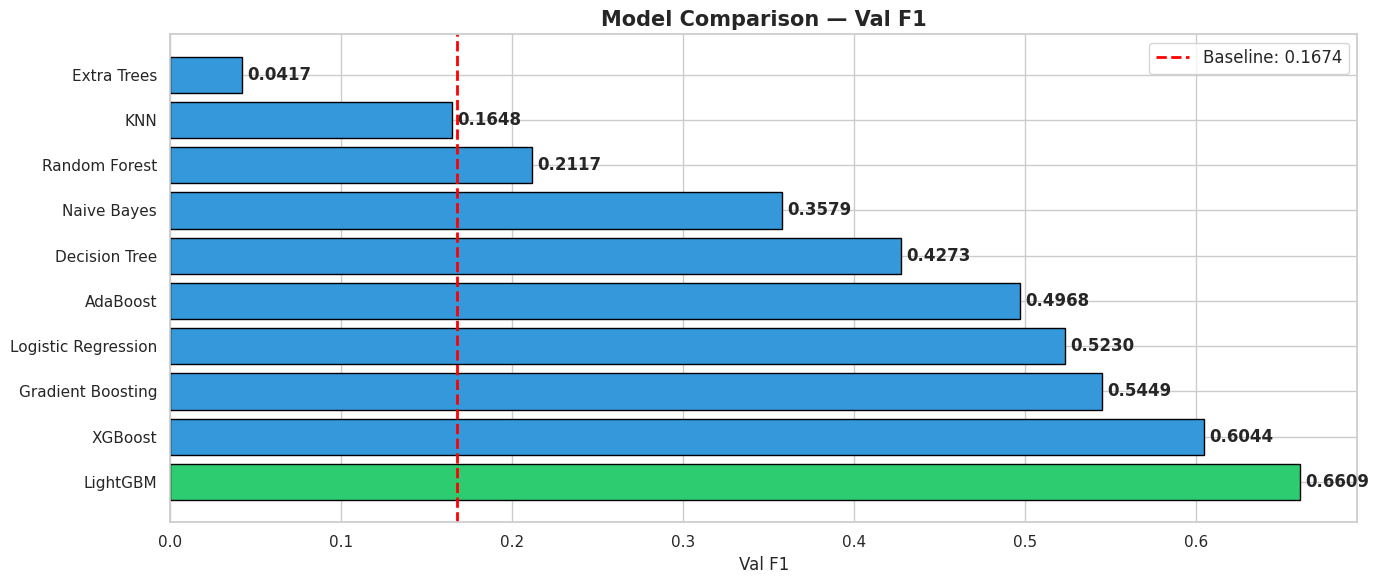

In [ ]:
# --- Model comparison chart ---
fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#2ecc71' if n == best_model_name else '#3498db' for n in results_df.index]
bars = ax.barh(results_df.index, results_df[sort_col].astype(float), color=colors, edgecolor='black')
if PROBLEM_TYPE == 'classification':
    ax.axvline(BASELINE_F1, color='red', linestyle='--', lw=2, label=f'Baseline: {BASELINE_F1:.4f}')
ax.set_xlabel(sort_col)
ax.set_title(f'Model Comparison — {sort_col}', fontsize=15, fontweight='bold')
for bar, val in zip(bars, results_df[sort_col].astype(float)):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2, f'{val:.4f}', ha='left', va='center', fontweight='bold')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

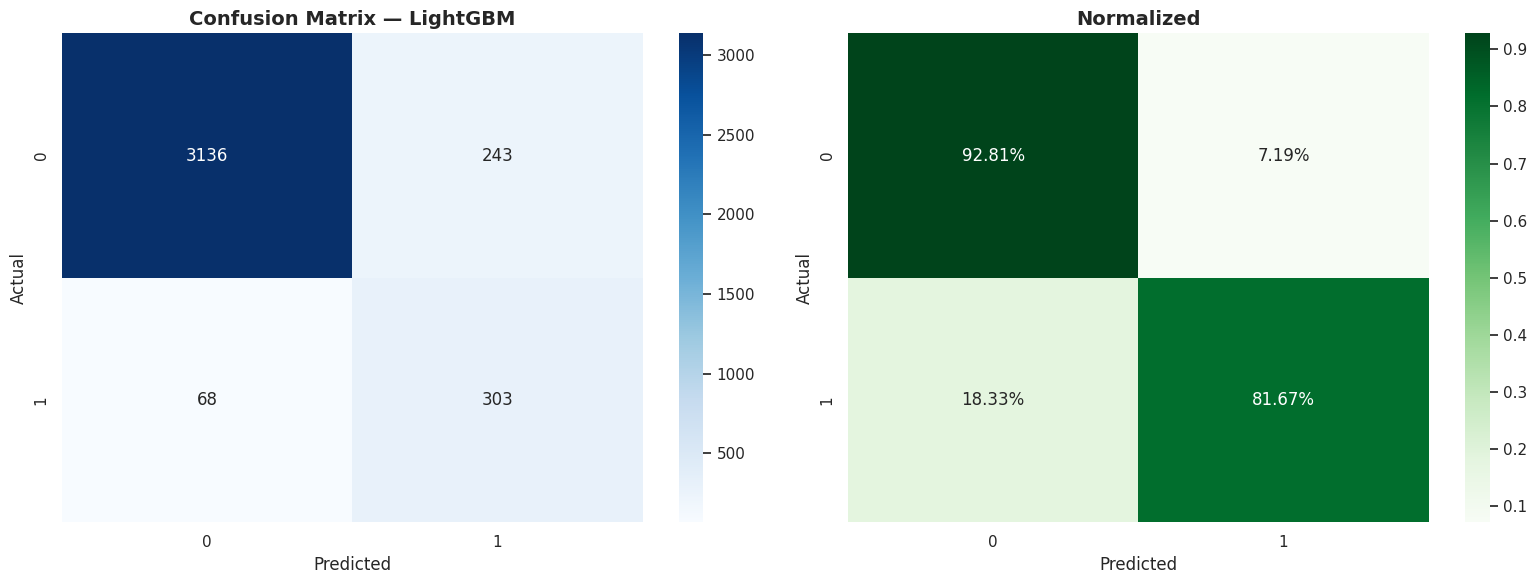


📋 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.93      0.95      3379
           1       0.55      0.82      0.66       371

    accuracy                           0.92      3750
   macro avg       0.77      0.87      0.81      3750
weighted avg       0.94      0.92      0.92      3750



In [ ]:
# --- Confusion Matrix / Prediction Plot ---
y_pred_best = best_model.predict(X_val)

if PROBLEM_TYPE == 'classification':
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    cm = confusion_matrix(y_val, y_pred_best)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title(f'Confusion Matrix — {best_model_name}', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', ax=axes[1])
    axes[1].set_title('Normalized', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
    plt.tight_layout(); plt.show()
    print('\n📋 Classification Report:')
    print(classification_report(y_val, y_pred_best))
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    axes[0].scatter(y_val, y_pred_best, alpha=0.4, s=10)
    axes[0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
    axes[0].set_title('Actual vs Predicted', fontsize=14, fontweight='bold')
    residuals = y_val - y_pred_best
    axes[1].scatter(y_pred_best, residuals, alpha=0.4, s=10, color='#e74c3c')
    axes[1].axhline(0, color='black', linestyle='--')
    axes[1].set_title('Residuals', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()

---
## 1️⃣5️⃣ Error Analysis

🔍 ERROR ANALYSIS
  ❌ Misclassified: 311 / 3750 (8.3%)


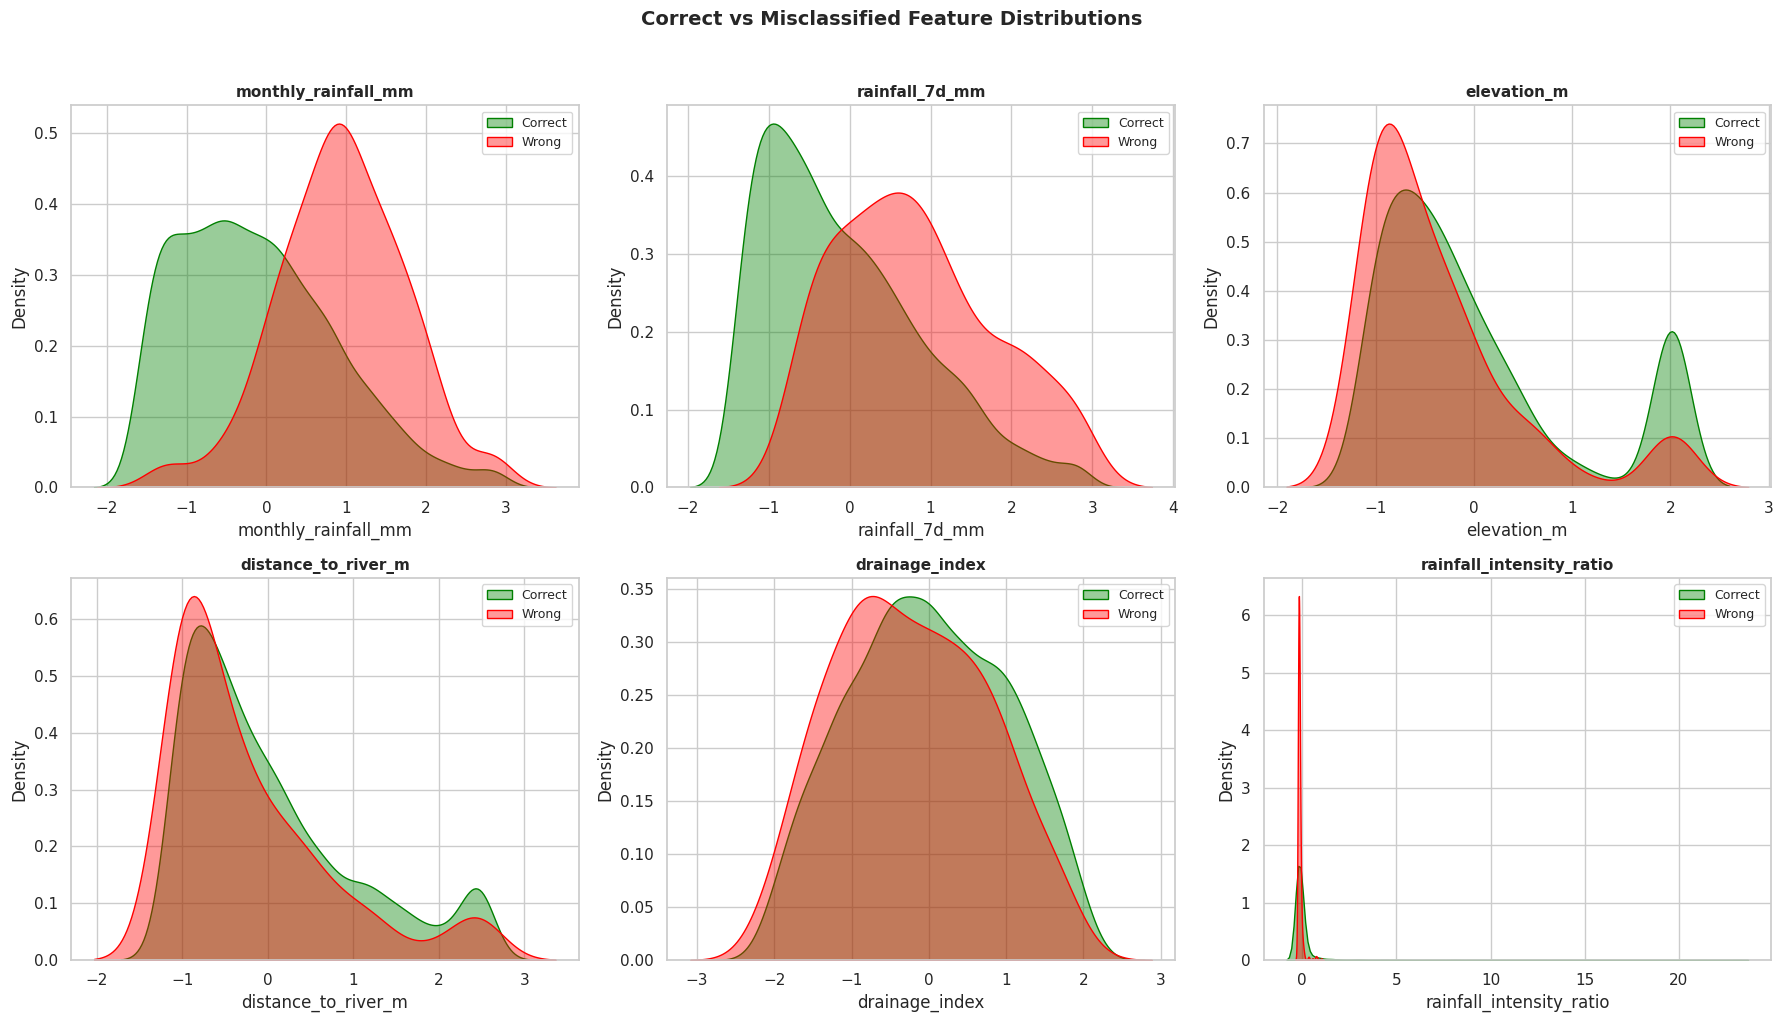

In [ ]:
# ============================================================
# 15. ERROR ANALYSIS
# ============================================================

print(f'{"="*60}')
print('🔍 ERROR ANALYSIS')
print(f'{"="*60}')

if PROBLEM_TYPE == 'classification':
    correct_mask = (y_pred_best == y_val.values)
    n_wrong = int((~correct_mask).sum())
    print(f'  ❌ Misclassified: {n_wrong} / {len(y_val)} ({n_wrong / len(y_val) * 100:.1f}%)')

    # Feature distributions: correct vs wrong
    diff_means = {}
    for col in X_val.columns[:20]:
        mean_c = X_val.loc[correct_mask, col].mean()
        mean_w = X_val.loc[~correct_mask, col].mean()
        diff_means[col] = abs(mean_c - mean_w) if not (np.isnan(mean_c) or np.isnan(mean_w)) else 0

    top_diff = sorted(diff_means.items(), key=lambda x: x[1], reverse=True)[:6]
    n_plot = min(6, len(top_diff))
    if n_plot > 0:
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        axes = axes.flatten()
        for i in range(n_plot):
            col = top_diff[i][0]
            d_correct = X_val.loc[correct_mask, col].dropna()
            d_wrong = X_val.loc[~correct_mask, col].dropna()
            if len(d_correct) > 1 and d_correct.std() > 0:
                sns.kdeplot(d_correct, ax=axes[i], fill=True, alpha=0.4, label='Correct', color='green')
            if len(d_wrong) > 1 and d_wrong.std() > 0:
                sns.kdeplot(d_wrong, ax=axes[i], fill=True, alpha=0.4, label='Wrong', color='red')
            axes[i].set_title(col, fontsize=11, fontweight='bold')
            axes[i].legend(fontsize=9)
        for j in range(n_plot, len(axes)):
            axes[j].set_visible(False)
        plt.suptitle('Correct vs Misclassified Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout(); plt.show()
else:
    residuals = y_val - y_pred_best
    print(f'  Mean Error:  {residuals.mean():.4f}')
    print(f'  Error Std:   {residuals.std():.4f}')

---
## 1️⃣2️⃣ Cross Validation + 1️⃣6️⃣ Optimization

🚀 HYPERPARAMETER TUNING — LightGBM
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Best params: {'num_leaves': 50, 'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.05}
   Best CV score: 0.9221

📊 5-Fold CV:
   Scores: [0.9244 0.9241 0.92   0.9201 0.9221]
   Mean:   0.9221 ± 0.0019


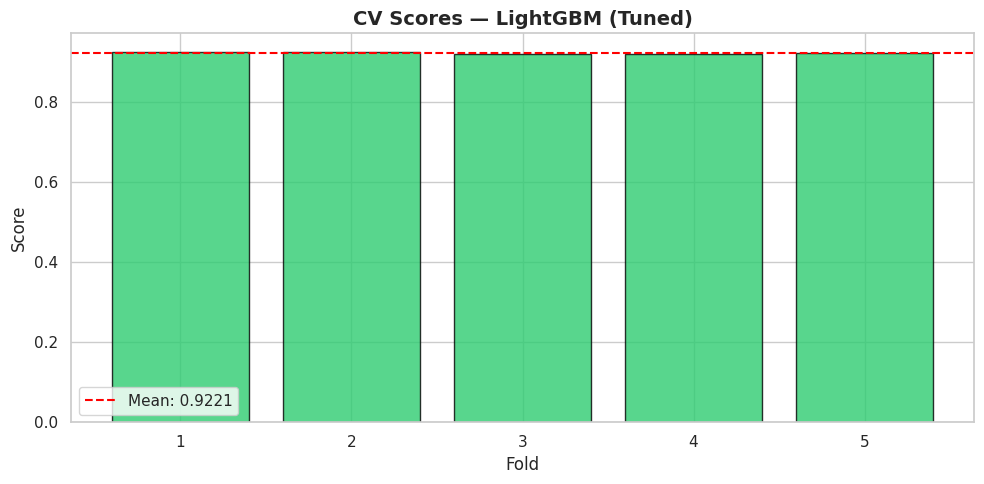

In [ ]:
# ============================================================
# 12 + 16. CROSS VALIDATION + HYPERPARAMETER TUNING
# ============================================================
from sklearn.model_selection import RandomizedSearchCV, cross_val_score

print(f'{"="*60}')
print(f'🚀 HYPERPARAMETER TUNING — {best_model_name}')
print(f'{"="*60}')

param_grids = {
    'Random Forest': {'n_estimators': [100,200,300,500], 'max_depth': [None,10,20,30], 'min_samples_split': [2,5,10], 'min_samples_leaf': [1,2,4], 'max_features': ['sqrt','log2',None]},
    'Gradient Boosting': {'n_estimators': [100,200,300], 'learning_rate': [0.01,0.05,0.1,0.2], 'max_depth': [3,5,7,10], 'subsample': [0.7,0.8,0.9,1.0]},
    'XGBoost': {'n_estimators': [100,200,300,500], 'learning_rate': [0.01,0.05,0.1,0.2], 'max_depth': [3,5,7,10], 'subsample': [0.7,0.8,0.9], 'colsample_bytree': [0.7,0.8,0.9,1.0]},
    'LightGBM': {'n_estimators': [100,200,300,500], 'learning_rate': [0.01,0.05,0.1,0.2], 'max_depth': [-1,5,10,20], 'num_leaves': [31,50,100]},
    'Extra Trees': {'n_estimators': [100,200,300,500], 'max_depth': [None,10,20,30], 'min_samples_split': [2,5,10]},
    'KNN': {'n_neighbors': [3,5,7,9,11,15], 'weights': ['uniform','distance']},
    'Logistic Regression': {'C': [0.01,0.1,1,10,100], 'solver': ['lbfgs','liblinear']}
}

if best_model_name in param_grids:
    scoring = 'f1_weighted' if PROBLEM_TYPE == 'classification' else 'neg_root_mean_squared_error'
    search = RandomizedSearchCV(
        best_model, param_grids[best_model_name],
        n_iter=30, cv=5, scoring=scoring, random_state=RANDOM_STATE, n_jobs=-1, verbose=1
    )
    search.fit(X_train, y_train)
    print(f'\n✅ Best params: {search.best_params_}')
    print(f'   Best CV score: {search.best_score_:.4f}')
    best_model = search.best_estimator_
    best_model_name = f'{best_model_name} (Tuned)'
else:
    print(f'  No tuning grid for {best_model_name}. Using defaults.')

# Cross-validation
scoring = 'f1_weighted' if PROBLEM_TYPE == 'classification' else 'neg_root_mean_squared_error'
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring=scoring, n_jobs=-1)

print(f'\n📊 5-Fold CV:')
print(f'   Scores: {cv_scores.round(4)}')
print(f'   Mean:   {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, 6), cv_scores, color='#2ecc71', edgecolor='black', alpha=0.8)
ax.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean: {cv_scores.mean():.4f}')
ax.set_xlabel('Fold'); ax.set_ylabel('Score')
ax.set_title(f'CV Scores — {best_model_name}', fontsize=14, fontweight='bold')
ax.legend(); ax.set_xticks(range(1, 6))
plt.tight_layout(); plt.show()

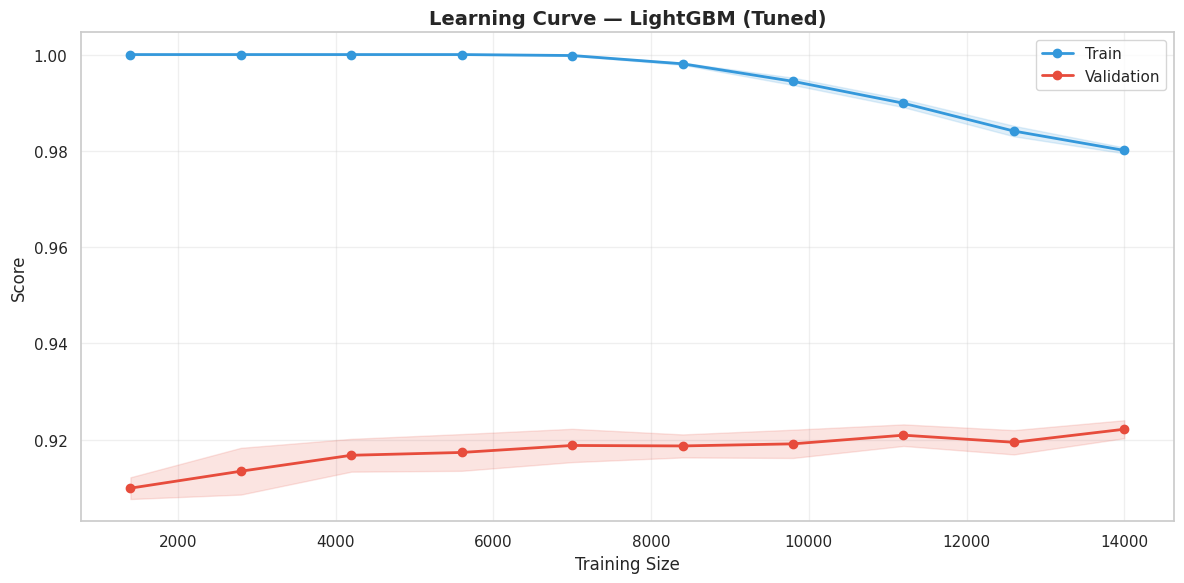

  Gap: 0.0579 → ⚠️ Possible overfitting


In [ ]:
# --- Learning Curves ---
from sklearn.model_selection import learning_curve

scoring_lc = 'f1_weighted' if PROBLEM_TYPE == 'classification' else 'neg_root_mean_squared_error'
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), scoring=scoring_lc
)
t_mean = train_scores.mean(axis=1); t_std = train_scores.std(axis=1)
v_mean = val_scores.mean(axis=1); v_std = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(train_sizes, t_mean, 'o-', color='#3498db', label='Train', lw=2)
ax.fill_between(train_sizes, t_mean - t_std, t_mean + t_std, alpha=0.15, color='#3498db')
ax.plot(train_sizes, v_mean, 'o-', color='#e74c3c', label='Validation', lw=2)
ax.fill_between(train_sizes, v_mean - v_std, v_mean + v_std, alpha=0.15, color='#e74c3c')
ax.set_title(f'Learning Curve — {best_model_name}', fontsize=14, fontweight='bold')
ax.set_xlabel('Training Size'); ax.set_ylabel('Score')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

gap = abs(t_mean[-1] - v_mean[-1])
print(f'  Gap: {gap:.4f} → {"✅ No overfitting" if gap < 0.05 else "⚠️ Possible overfitting"}')

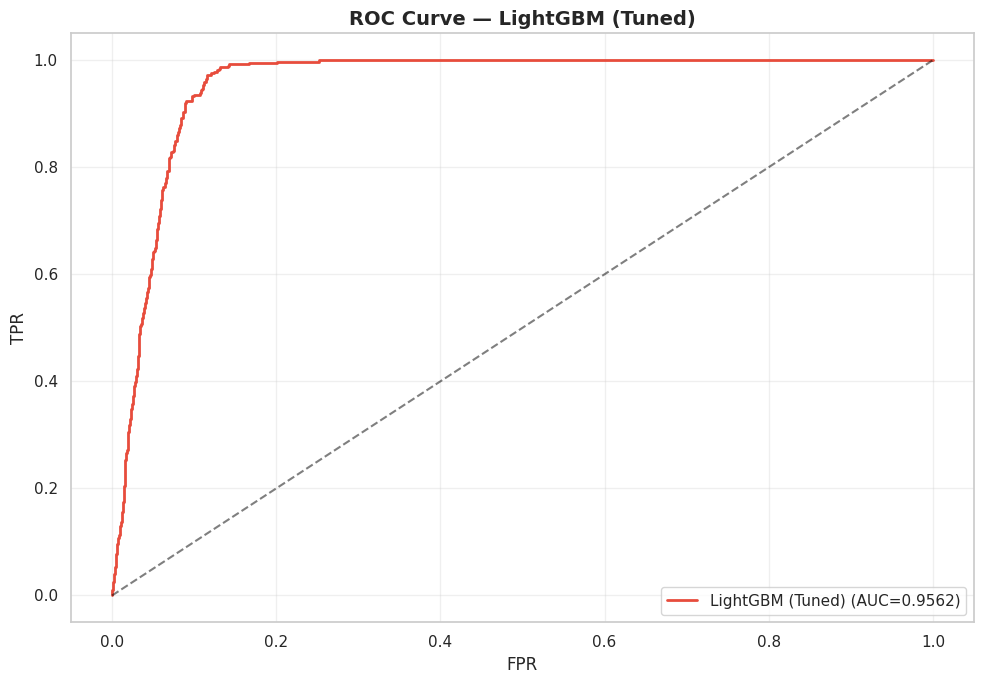

In [ ]:
# --- ROC Curve ---
if PROBLEM_TYPE == 'classification' and hasattr(best_model, 'predict_proba'):
    from sklearn.metrics import roc_curve, auc
    fig, ax = plt.subplots(figsize=(10, 7))
    if metadata['n_classes'] == 2:
        yp = best_model.predict_proba(X_val)[:, 1]
        fpr, tpr, _ = roc_curve(y_val, yp)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'{best_model_name} (AUC={roc_auc:.4f})')
    else:
        from sklearn.preprocessing import label_binarize
        y_val_bin = label_binarize(y_val, classes=metadata['class_labels'])
        yp = best_model.predict_proba(X_val)
        for idx_cls, cls in enumerate(metadata['class_labels']):
            fpr, tpr, _ = roc_curve(y_val_bin[:, idx_cls], yp[:, idx_cls])
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, lw=2, label=f'Class {cls} (AUC={roc_auc:.4f})')
    ax.plot([0,1],[0,1],'k--', alpha=0.5)
    ax.set_title(f'ROC Curve — {best_model_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

---
## 1️⃣7️⃣ Explainability

🧠 EXPLAINABILITY
  Computing permutation importance...


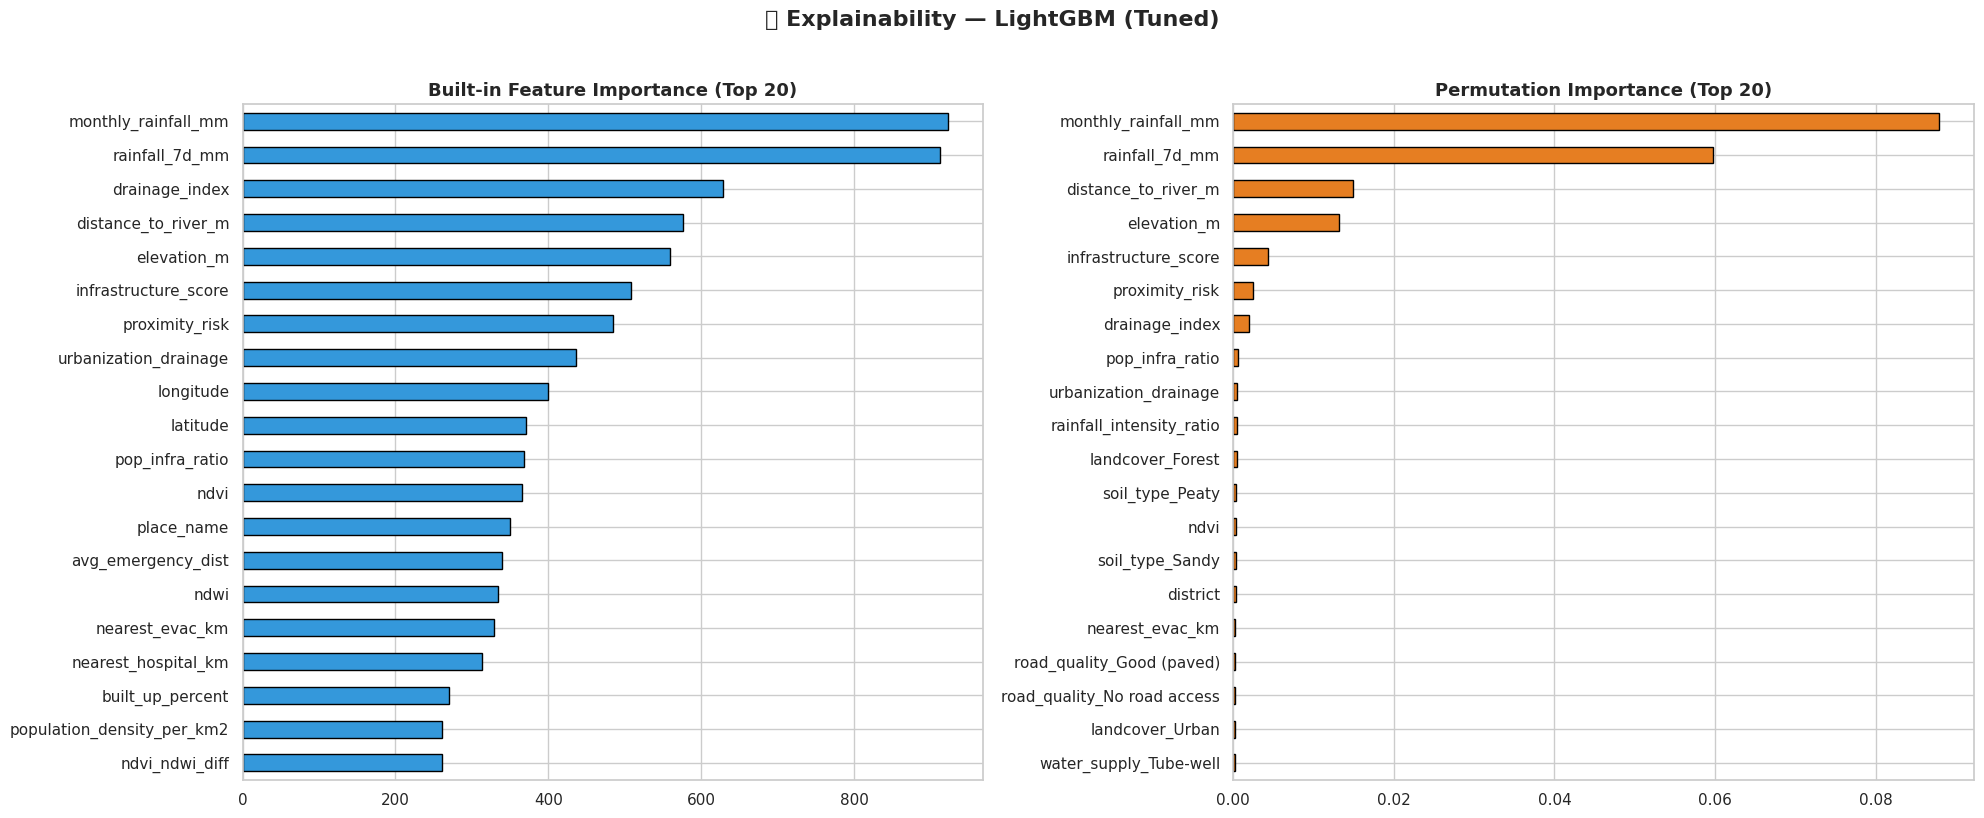


📌 Top 10 by Permutation Importance:
    1. monthly_rainfall_mm: 0.0879
    2. rainfall_7d_mm: 0.0598
    3. distance_to_river_m: 0.0150
    4. elevation_m: 0.0131
    5. infrastructure_score: 0.0043
    6. proximity_risk: 0.0024
    7. drainage_index: 0.0020
    8. pop_infra_ratio: 0.0006
    9. urbanization_drainage: 0.0004
   10. rainfall_intensity_ratio: 0.0004


In [ ]:
# ============================================================
# 17. EXPLAINABILITY
# ============================================================
from sklearn.inspection import permutation_importance

print(f'{"="*60}')
print('🧠 EXPLAINABILITY')
print(f'{"="*60}')

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Built-in importance
if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=True)
    imp.tail(20).plot(kind='barh', ax=axes[0], color='#3498db', edgecolor='black')
    axes[0].set_title('Built-in Feature Importance (Top 20)', fontsize=13, fontweight='bold')
elif hasattr(best_model, 'coef_'):
    coefs = best_model.coef_[0] if best_model.coef_.ndim > 1 else best_model.coef_
    imp = pd.Series(np.abs(coefs), index=X_train.columns).sort_values(ascending=True)
    imp.tail(20).plot(kind='barh', ax=axes[0], color='#e74c3c', edgecolor='black')
    axes[0].set_title('Feature Coefficients (Top 20)', fontsize=13, fontweight='bold')
else:
    axes[0].text(0.5, 0.5, 'No built-in importance', transform=axes[0].transAxes, ha='center', fontsize=14)

# Permutation importance
print('  Computing permutation importance...')
perm_scoring = 'f1_weighted' if PROBLEM_TYPE == 'classification' else 'neg_root_mean_squared_error'
perm_result = permutation_importance(best_model, X_val, y_val, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1, scoring=perm_scoring)
perm_imp = pd.Series(perm_result.importances_mean, index=X_val.columns).sort_values(ascending=True)
perm_imp.tail(20).plot(kind='barh', ax=axes[1], color='#e67e22', edgecolor='black')
axes[1].set_title('Permutation Importance (Top 20)', fontsize=13, fontweight='bold')

plt.suptitle(f'🧠 Explainability — {best_model_name}', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print('\n📌 Top 10 by Permutation Importance:')
for rank, (feat, score) in enumerate(perm_imp.tail(10).sort_values(ascending=False).items(), 1):
    print(f'   {rank:2d}. {feat}: {score:.4f}')


🔬 SHAP Analysis...


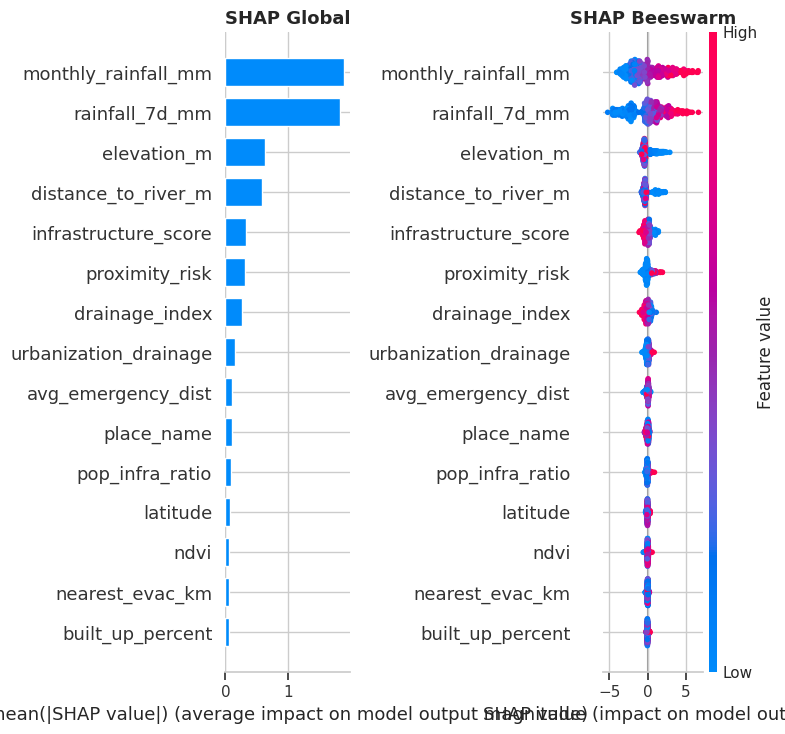

In [ ]:
# --- SHAP (if installed) ---
try:
    import shap
    print('\n🔬 SHAP Analysis...')
    X_shap = X_val.sample(min(500, len(X_val)), random_state=RANDOM_STATE)
    try:
        explainer = shap.TreeExplainer(best_model)
        shap_values = explainer.shap_values(X_shap)
    except Exception:
        try:
            bg = shap.sample(X_train, 100)
            explainer = shap.KernelExplainer(best_model.predict, bg)
            shap_values = explainer.shap_values(X_shap)
        except Exception as e:
            print(f'  SHAP failed: {e}')
            shap_values = None
    if shap_values is not None:
        sv = shap_values[1] if isinstance(shap_values, list) and len(shap_values) > 1 else (shap_values[0] if isinstance(shap_values, list) else shap_values)
        fig, axes = plt.subplots(1, 2, figsize=(20, 8))
        plt.sca(axes[0])
        shap.summary_plot(sv, X_shap, plot_type='bar', show=False, max_display=15)
        axes[0].set_title('SHAP Global', fontsize=13, fontweight='bold')
        plt.sca(axes[1])
        shap.summary_plot(sv, X_shap, show=False, max_display=15)
        axes[1].set_title('SHAP Beeswarm', fontsize=13, fontweight='bold')
        plt.tight_layout(); plt.show()
except ImportError:
    print('  ⚠️ SHAP not installed. pip install shap')

---
## 1️⃣9️⃣ Save Model + Download

In [ ]:
# ============================================================
# 19. SAVE MODEL + DOWNLOAD
# ============================================================

joblib.dump(best_model, 'model.pkl')

model_metadata = {
    'model_name': best_model_name,
    'model_type': type(best_model).__name__,
    'problem_type': PROBLEM_TYPE,
    'n_features': int(X_train.shape[1]),
    'feature_names': list(X_train.columns),
    'target_column': TARGET_COL,
    'cv_score_mean': float(cv_scores.mean()),
    'cv_score_std': float(cv_scores.std()),
    'baseline_beaten': True
}
with open('model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=2)

print(f'{"="*60}')
print('💾 MODEL SAVED')
print(f'{"="*60}')
print(f'  📄 model.pkl')
print(f'  📄 model_metadata.json')
print(f'  🏆 {best_model_name} — CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

# Download
try:
    from google.colab import files as colab_files
    print('\n📥 Downloading...')
    colab_files.download('model.pkl')
    colab_files.download('model_metadata.json')
    print('✅ Downloaded!')
except ImportError:
    import os
    print(f'\n📂 Files saved in: {os.getcwd()}')

print(f'\n🎉 Training pipeline complete!')

💾 MODEL SAVED
  📄 model.pkl
  📄 model_metadata.json
  🏆 LightGBM (Tuned) — CV: 0.9221 ± 0.0019

📥 Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded!

🎉 Training pipeline complete!
